# Exploratory Data Analysis - Visualization

  RED WINE QUALITY — EXPLORATORY DATA ANALYSIS

Shape: 1599 rows × 12 columns
Missing values: 0

--- Descriptive Statistics ---
       fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  free sulfur dioxide  total sulfur dioxide  density       pH  sulphates  alcohol  quality
count        1599.00           1599.00      1599.00         1599.00    1599.00              1599.00               1599.00  1599.00  1599.00    1599.00  1599.00  1599.00
mean            8.32              0.53         0.27            2.54       0.09                15.87                 46.47     1.00     3.31       0.66    10.42     5.64
std             1.74              0.18         0.19            1.41       0.05                10.46                 32.90     0.00     0.15       0.17     1.07     0.81
min             4.60              0.12         0.00            0.90       0.01                 1.00                  6.00     0.99     2.74       0.33     8.40     3.00
25%             7.10       

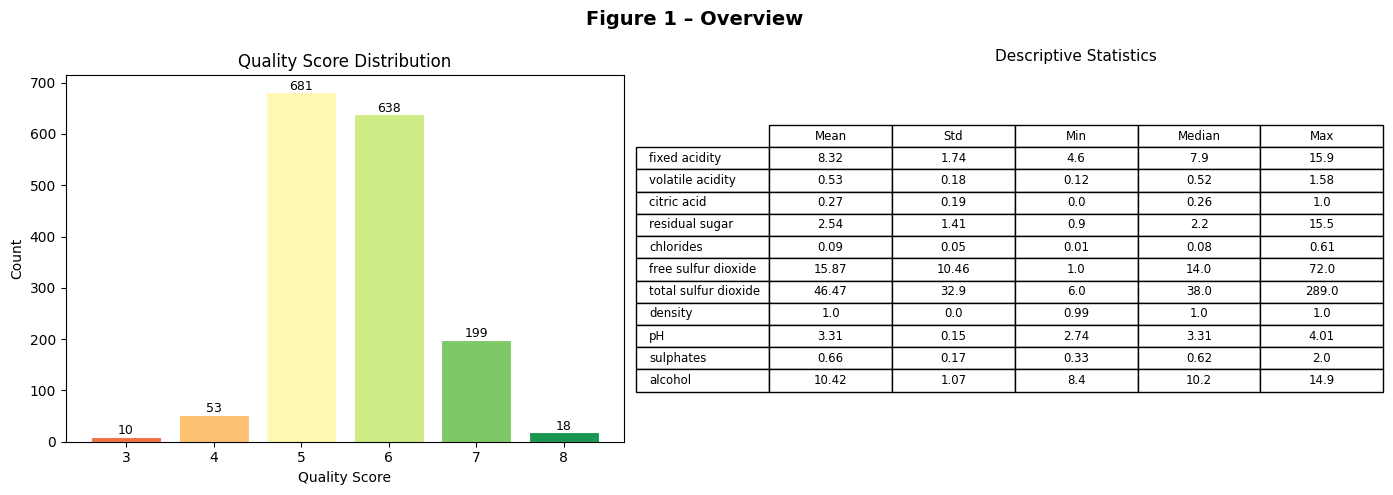


Fig 1 saved.


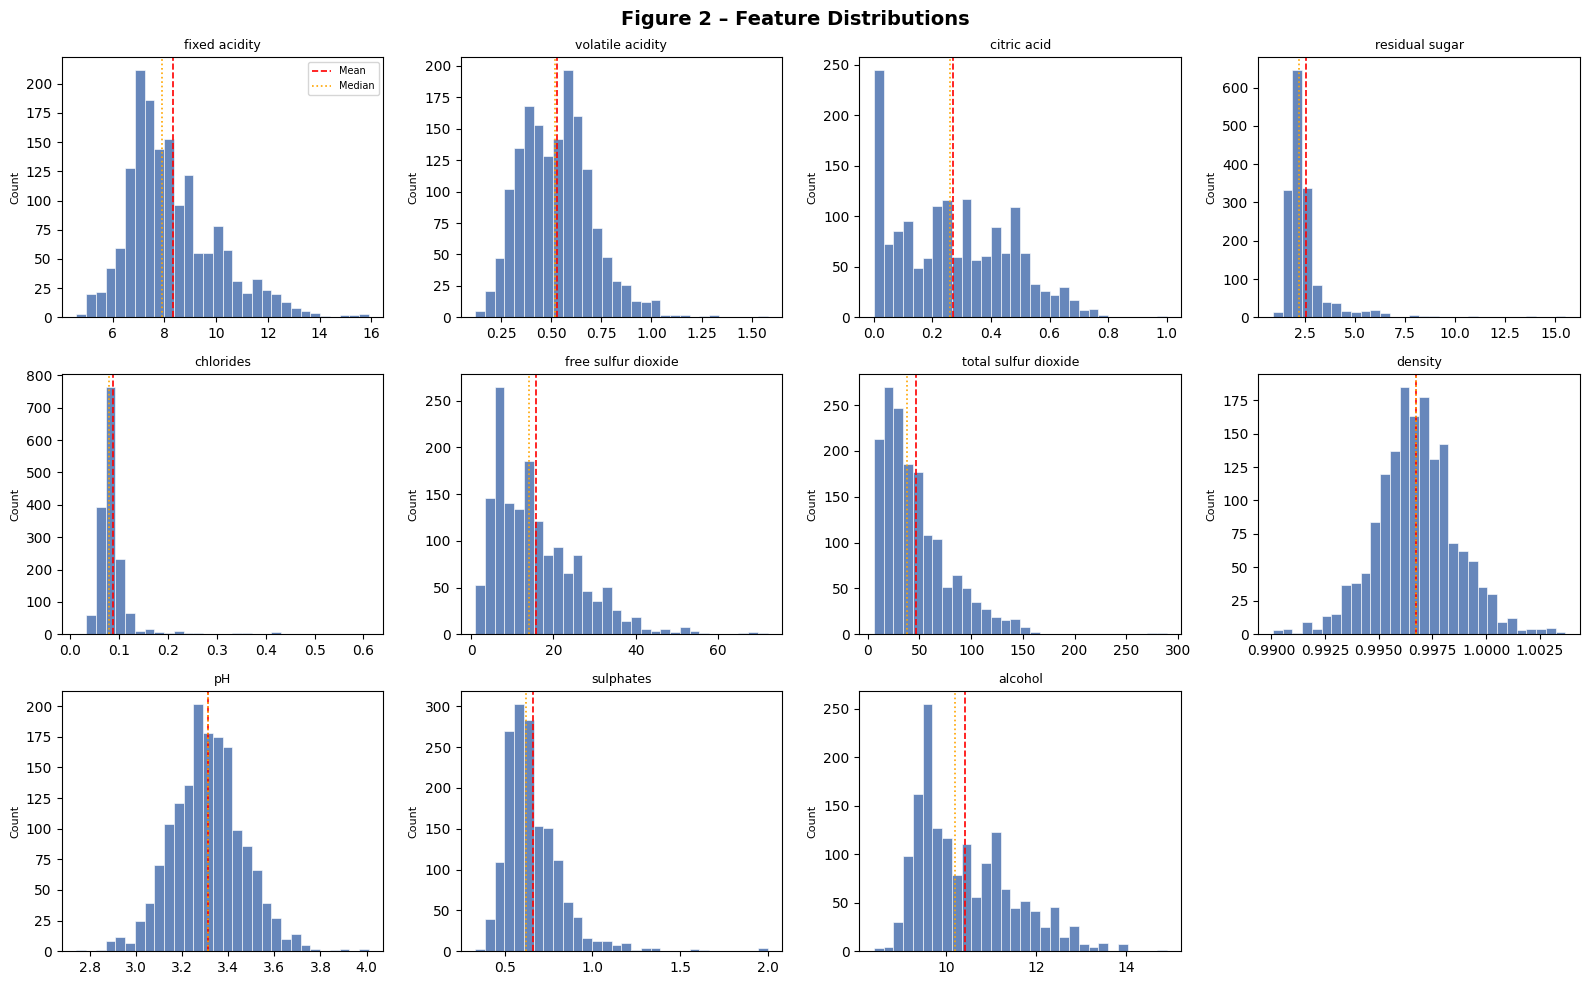

Fig 2 saved.


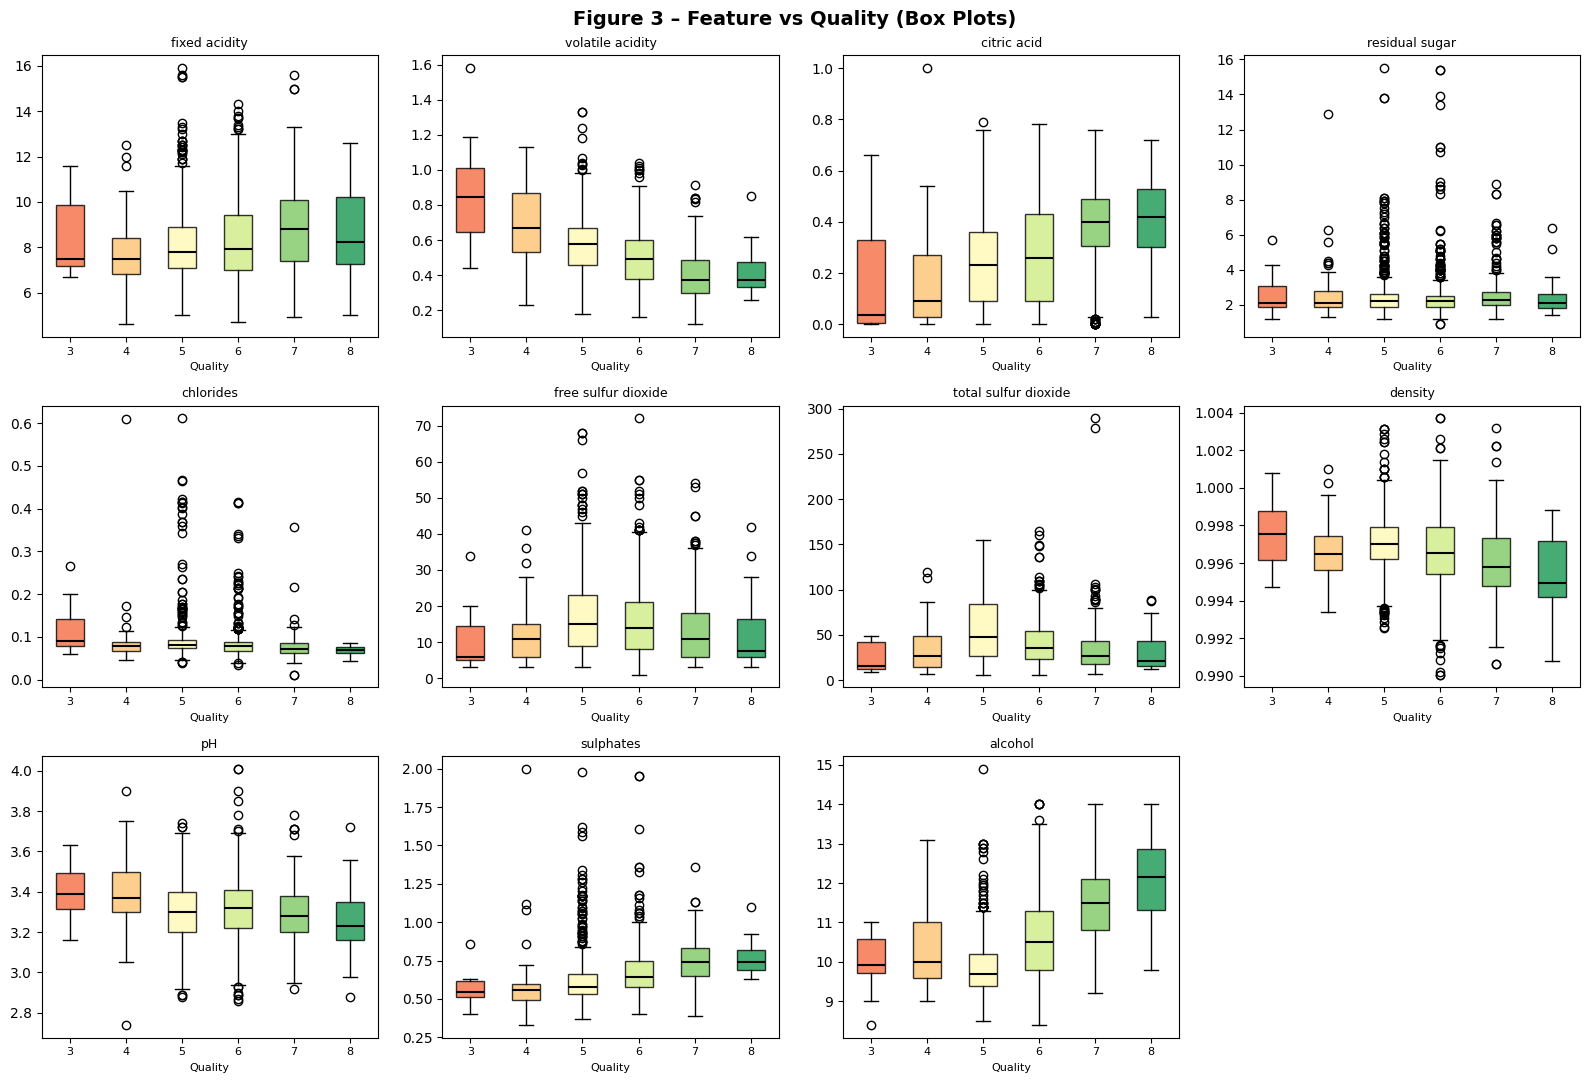

Fig 3 saved.


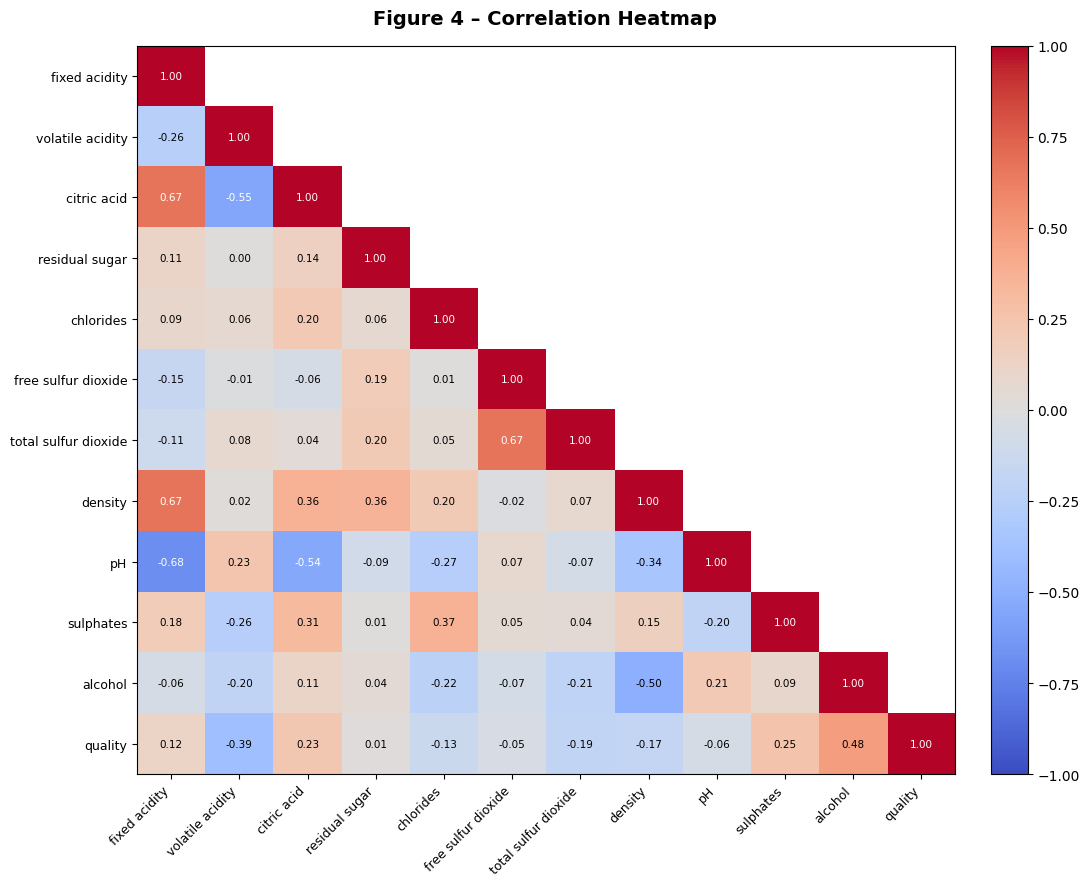

Fig 4 saved.


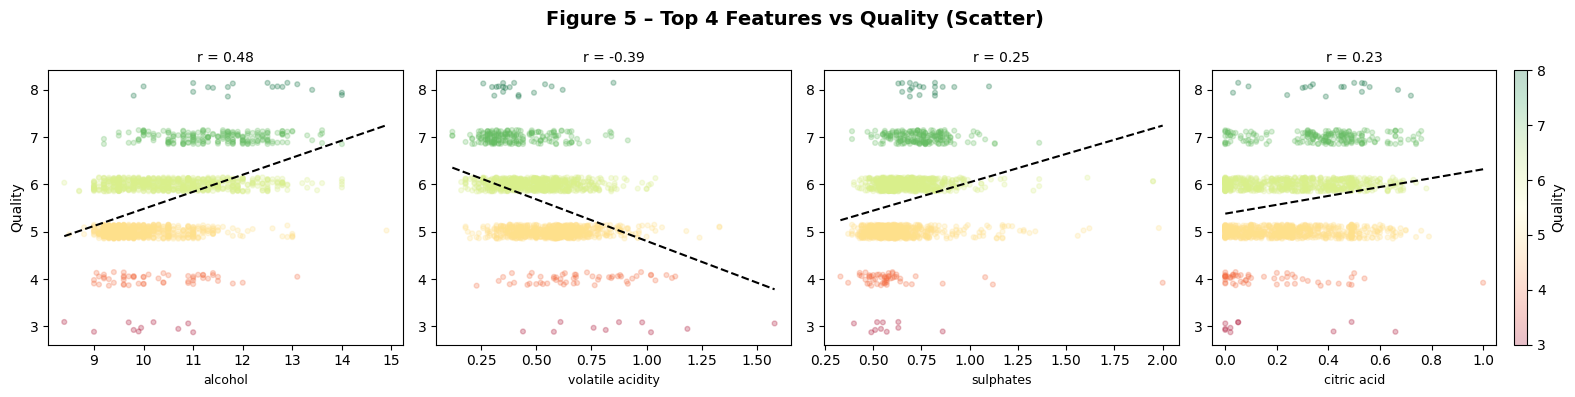

Fig 5 saved.

All done! 5 figures saved.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# ── Load data ──────────────────────────────────────────────────────────────
cols = ["fixed acidity","volatile acidity","citric acid","residual sugar",
        "chlorides","free sulfur dioxide","total sulfur dioxide","density",
        "pH","sulphates","alcohol","quality"]
df = pd.read_csv("winequality-red-1.csv", sep=";", skiprows=1, header=None, names=cols)
features = [c for c in cols if c != "quality"]

# ── 1. Basic info ──────────────────────────────────────────────────────────
print("=" * 55)
print("  RED WINE QUALITY — EXPLORATORY DATA ANALYSIS")
print("=" * 55)
print(f"\nShape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"Missing values: {df.isnull().sum().sum()}")
print("\n--- Descriptive Statistics ---")
print(df.describe().round(2).to_string())
print("\n--- Quality Distribution ---")
counts = df["quality"].value_counts().sort_index()
for q, n in counts.items():
    pct = n / len(df) * 100
    print(f"  Grade {q}: {n:4d} wines  ({pct:.1f}%)")


# ── Figure 1: Quality distribution + stats table ───────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Figure 1 – Overview", fontsize=14, fontweight="bold")

ax = axes[0]
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(counts)))
bars = ax.bar(counts.index, counts.values, color=colors, edgecolor="white", linewidth=0.8)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            str(val), ha="center", fontsize=9)
ax.set_xlabel("Quality Score"); ax.set_ylabel("Count")
ax.set_title("Quality Score Distribution"); ax.set_xticks(counts.index)

ax2 = axes[1]; ax2.axis("off")
stats = df[features].describe().T[["mean","std","min","50%","max"]].round(2)
stats.columns = ["Mean","Std","Min","Median","Max"]
table = ax2.table(cellText=stats.values, rowLabels=stats.index,
                  colLabels=stats.columns, cellLoc="center", loc="center")
table.auto_set_font_size(False); table.set_fontsize(8.5); table.scale(1.1, 1.4)
ax2.set_title("Descriptive Statistics", fontsize=11, pad=10)
plt.tight_layout(); plt.savefig("figures/eda_fig1_overview.png", dpi=150, bbox_inches="tight")
plt.show(); plt.close(); print("\nFig 1 saved.")


# ── Figure 2: Histograms ───────────────────────────────────────────────────
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
fig.suptitle("Figure 2 – Feature Distributions", fontsize=14, fontweight="bold")
axes = axes.flatten()
for i, feat in enumerate(features):
    ax = axes[i]
    ax.hist(df[feat], bins=30, color="#4C72B0", edgecolor="white", linewidth=0.5, alpha=0.85)
    ax.axvline(df[feat].mean(),   color="red",    linestyle="--", linewidth=1.2, label="Mean")
    ax.axvline(df[feat].median(), color="orange", linestyle=":",  linewidth=1.2, label="Median")
    ax.set_title(feat, fontsize=9); ax.set_ylabel("Count", fontsize=8)
    if i == 0: ax.legend(fontsize=7)
axes[-1].axis("off")
plt.tight_layout(); plt.savefig("figures/eda_fig2_histograms.png", dpi=150, bbox_inches="tight")
plt.show(); plt.close(); print("Fig 2 saved.")


# ── Figure 3: Box plots by quality ────────────────────────────────────────
fig, axes = plt.subplots(3, 4, figsize=(16, 11))
fig.suptitle("Figure 3 – Feature vs Quality (Box Plots)", fontsize=14, fontweight="bold")
axes = axes.flatten()
quality_levels = sorted(df["quality"].unique())
palette = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(quality_levels)))
for i, feat in enumerate(features):
    ax = axes[i]
    data_by_q = [df.loc[df["quality"] == q, feat].values for q in quality_levels]
    bp = ax.boxplot(data_by_q, patch_artist=True,
                    medianprops=dict(color="black", linewidth=1.5))
    for patch, color in zip(bp["boxes"], palette):
        patch.set_facecolor(color); patch.set_alpha(0.8)
    ax.set_xticklabels(quality_levels, fontsize=8)
    ax.set_title(feat, fontsize=9); ax.set_xlabel("Quality", fontsize=8)
axes[-1].axis("off")
plt.tight_layout(); plt.savefig("figures/eda_fig3_boxplots.png", dpi=150, bbox_inches="tight")
plt.show(); plt.close(); print("Fig 3 saved.")


# ── Figure 4: Correlation heatmap ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 9))
fig.suptitle("Figure 4 – Correlation Heatmap", fontsize=14, fontweight="bold")
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
corr_lower = corr.copy(); corr_lower[mask] = np.nan
im = ax.imshow(corr_lower, cmap="coolwarm", vmin=-1, vmax=1, aspect="auto")
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.set_xticks(range(len(corr.columns))); ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right", fontsize=9)
ax.set_yticklabels(corr.columns, fontsize=9)
for i in range(len(corr)):
    for j in range(len(corr)):
        if not mask[i, j]:
            val = corr_lower.iloc[i, j]
            ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                    fontsize=7.5, color="white" if abs(val) > 0.5 else "black")
plt.tight_layout(); plt.savefig("figures/eda_fig4_correlation.png", dpi=150, bbox_inches="tight")
plt.show(); plt.close(); print("Fig 4 saved.")


# ── Figure 5: Top 4 features vs quality scatter ───────────────────────────
top4 = df.corr()["quality"].drop("quality").abs().sort_values(ascending=False).head(4).index.tolist()
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle("Figure 5 – Top 4 Features vs Quality (Scatter)", fontsize=14, fontweight="bold")
for ax, feat in zip(axes, top4):
    jitter = np.random.RandomState(42).uniform(-0.15, 0.15, len(df))
    sc = ax.scatter(df[feat], df["quality"] + jitter, alpha=0.25, s=12,
                    c=df["quality"], cmap="RdYlGn", vmin=3, vmax=8)
    m, b = np.polyfit(df[feat], df["quality"], 1)
    x_line = np.linspace(df[feat].min(), df[feat].max(), 100)
    ax.plot(x_line, m*x_line + b, color="black", linewidth=1.5, linestyle="--")
    r = df[[feat, "quality"]].corr().iloc[0, 1]
    ax.set_xlabel(feat, fontsize=9)
    ax.set_ylabel("Quality" if ax == axes[0] else "")
    ax.set_title(f"r = {r:.2f}", fontsize=10)
plt.colorbar(sc, ax=axes[-1], label="Quality")
plt.tight_layout(); plt.savefig("figures/eda_fig5_scatter.png", dpi=150, bbox_inches="tight")
plt.show(); plt.close(); print("Fig 5 saved.")

print("\nAll done! 5 figures saved.")